# 06. Análise Exploratória — Defasagem de Aquisição (H7)

## Objetivo deste notebook

Testar se a Netflix acelerou a aquisição de lançamentos recentes, medindo o *lag* entre o
ano de produção do título (`release_year`) e o ano em que foi adicionado ao catálogo
(`year_added`).

## Hipótese coberta

| ID | Pergunta de Negócio | Métrica Operacional |
|---|---|---|
| **H7** | A Netflix acelerou a aquisição de lançamentos recentes? | `year_added - release_year`, agregado por ano de adição (média e mediana) |

## Decisões metodológicas herdadas

- **14 registros (0,16%)** com lag negativo são excluídos do cálculo agregado (`lag >= 0`),
  por refletirem um comportamento conhecido do dataset (atualização de ano de referência em
  novas temporadas), não erro de aquisição.
- 2021 excluído por ser ano parcial.
- Dado o achado da H4, esta análise também vai checar se anos de volume muito baixo
  (2008–2014) distorcem o lag médio, aplicando o mesmo filtro `MIN_YEARLY_VOLUME` já
  validado.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

NETFLIX_RED = "#E50914"
SILVER = "#B3B3B3"
BG_COLOR = "#141414"
GRID_COLOR = "#2A2A2A"
TEXT_COLOR = "#FFFFFF"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR, "axes.facecolor": BG_COLOR, "savefig.facecolor": BG_COLOR,
    "axes.edgecolor": GRID_COLOR, "axes.labelcolor": TEXT_COLOR, "axes.titlecolor": TEXT_COLOR,
    "text.color": TEXT_COLOR, "xtick.color": TEXT_COLOR, "ytick.color": TEXT_COLOR,
    "grid.color": GRID_COLOR, "grid.alpha": 0.5, "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.figsize": (12, 6), "legend.frameon": False,
})
df = pd.read_csv(r'C:\Users\lukin\OneDrive\Documentos\netflix_catalog_analysis\data\processed\netflix_titles_clean.csv')
df['date_added_clean'] = pd.to_datetime(df['date_added_clean'])

df_temp = df.dropna(subset=['date_added_clean']).copy()
df_temp = df_temp[df_temp['year_added'] <=2020]

MIN_YEARLY_VOLUME = 100
yearly_totals = df_temp.groupby('year_added').size()
years_valid = yearly_totals[yearly_totals >= MIN_YEARLY_VOLUME].index
df_temp = df_temp[df_temp['year_added'].isin(years_valid)].copy()

df_temp['lag_years'] = df_temp['year_added'] - df_temp['release_year']

n_negative = (df_temp['lag_years'] < 0).sum()
print(f"Anos considerados (volume >= {MIN_YEARLY_VOLUME}): {sorted(years_valid)}")
print(f"Registros com lag negativo (excluídos do agregado): {n_negative}")

df_lag_valid = df_temp[df_temp['lag_years'] >= 0].copy()
print(f"Registros válidos para H7: {len(df_lag_valid)}")

Anos considerados (volume >= 100): [2016.0, 2017.0, 2018.0, 2019.0, 2020.0]
Registros com lag negativo (excluídos do agregado): 13
Registros válidos para H7: 7148


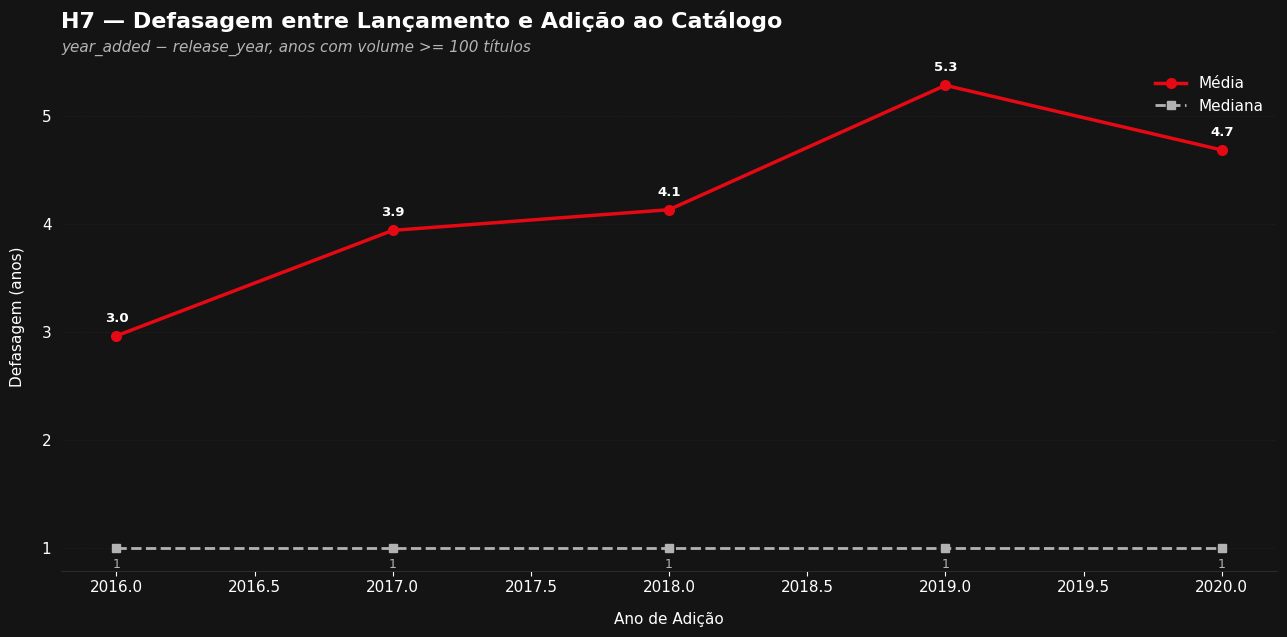

Lag médio em 2016: 2.96 anos
Lag médio em 2020: 4.69 anos


In [6]:
lag_by_year = df_lag_valid.groupby('year_added')['lag_years'].agg(['mean', 'median', 'count'])

fig, ax = plt.subplots(figsize=(13, 6.5), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

ax.plot(lag_by_year.index, lag_by_year['mean'], marker='o', markersize=7, linewidth=2.5,
        color=NETFLIX_RED, label='Média')
ax.plot(lag_by_year.index, lag_by_year['median'], marker='s', markersize=6, linewidth=2,
        linestyle='--', color=SILVER, label='Mediana')

for year in lag_by_year.index:
    ax.annotate(f"{lag_by_year.loc[year, 'mean']:.1f}", 
                (year, lag_by_year.loc[year, 'mean']),
                textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color=TEXT_COLOR, fontsize=9.5)
    ax.annotate(f"{lag_by_year.loc[year, 'median']:.0f}", 
                (year, lag_by_year.loc[year, 'median']),
                textcoords="offset points", xytext=(0,-15), ha='center', color=SILVER, fontsize=9)

ax.set_title("H7 — Defasagem entre Lançamento e Adição ao Catálogo", pad=25, loc='left', fontsize=16)
ax.text(0, 1.02, f"year_added − release_year, anos com volume >= {MIN_YEARLY_VOLUME} títulos",
        transform=ax.transAxes, color=SILVER, fontsize=11, style='italic')

ax.set_xlabel("Ano de Adição", labelpad=12)
ax.set_ylabel("Defasagem (anos)", labelpad=12)
ax.legend(loc='upper right', facecolor=BG_COLOR, edgecolor=GRID_COLOR)

ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(GRID_COLOR)
ax.tick_params(left=False, labelleft=True)
ax.yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Lag médio em {lag_by_year.index.min():.0f}: {lag_by_year['mean'].iloc[0]:.2f} anos")
print(f"Lag médio em 2020: {lag_by_year['mean'].iloc[-1]:.2f} anos")

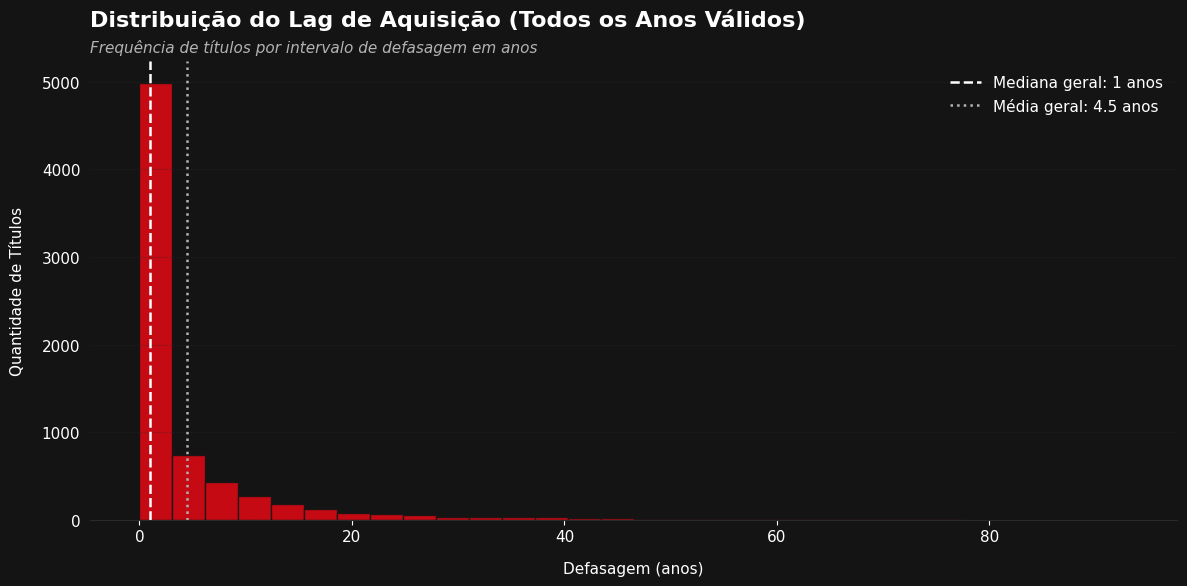

count    7148.000000
mean        4.500000
std         8.718127
min         0.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: lag_years, dtype: float64

Diferença média − mediana: 3.50 anos
Diferença relevante — distribuição assimétrica. Priorizar a MEDIANA na conclusão.


In [7]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

n, bins, patches = ax.hist(df_lag_valid['lag_years'], bins=30, color=NETFLIX_RED, alpha=0.85, edgecolor=BG_COLOR)
med_val = df_lag_valid['lag_years'].median()
mean_val = df_lag_valid['lag_years'].mean()

ax.axvline(med_val, color=TEXT_COLOR, linestyle='--', linewidth=1.8,
           label=f"Mediana geral: {med_val:.0f} anos")
ax.axvline(mean_val, color=SILVER, linestyle=':', linewidth=1.8,
           label=f"Média geral: {mean_val:.1f} anos")

ax.set_title("Distribuição do Lag de Aquisição (Todos os Anos Válidos)", pad=25, loc='left', fontsize=16)
ax.text(0, 1.02, "Frequência de títulos por intervalo de defasagem em anos",
        transform=ax.transAxes, color=SILVER, fontsize=11, style='italic')

ax.set_xlabel("Defasagem (anos)", labelpad=12)
ax.set_ylabel("Quantidade de Títulos", labelpad=12)
ax.legend(loc='upper right', facecolor=BG_COLOR, edgecolor=GRID_COLOR)

ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(GRID_COLOR)
ax.tick_params(left=False, labelleft=True)
ax.yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(df_lag_valid['lag_years'].describe())
skew_check = df_lag_valid['lag_years'].mean() - df_lag_valid['lag_years'].median()
print(f"\nDiferença média − mediana: {skew_check:.2f} anos")
if abs(skew_check) > 1:
    print("Diferença relevante — distribuição assimétrica. Priorizar a MEDIANA na conclusão.")
else:
    print("Média e mediana próximas — distribuição razoavelmente simétrica.")